# Entwicklung der Menschenrechte weltweit:
## Veränderungen im Human Rights Index (1950-2024)
**Datum:**
<span style="color:blue; font-weight:bold"> 21. Dezember 2025</span>  <img src="ZHAW.png" width="200" style="float:right; margin:10px">


**Institution:** ZHAW
Departement Life Sciences und Facility Management
(Abteilung Informatik)

**Gruppenmitglieder:**


Alessandro Zandt 


- E-Mail: zandtale@students.zhaw.ch


David Hascher


- E-Mail: haschdav@students.zhaw.ch


Tauland Strellci


- E-Mail: streltau@students.zhaw.ch


**Kurzer Projektbeschrieb:**


In diesem Projekt analysieren wir die zeitliche Entwicklung des Human Rights Index für verschiedene Länder. Im ersten Teil werden allgemeine Statistiken für den gesamten Datensatz präsentiert. Im zweiten Teil wird eine auf die Fragestellung zugeschnittene Auswahl der Daten erneut analysiert. Dies dient sowohl der Herleitung der Forschungsfrage als auch dazu, dem Leser eigene Interpretationen zu ermöglichen.
Der Datensatz Human Rights Index von V-Dem misst, wie stark grundlegende Menschenrechte in einzelnen Ländern geschützt sind. Der Index basiert auf Expertenschätzungen und umfasst zentrale Bereiche wie:

- Schutz vor staatlicher Gewalt (Tortur, politische Morde, Zwangsarbeit)

- Rechte auf Eigentum

- Bewegungsfreiheit

- Religionsfreiheit

- Meinungs- und Pressefreiheit

- Vereinigungsfreiheit

Der Index reicht von 0 bis 1, wobei 1 ein sehr hohes Schutzniveau der Menschenrechte darstellt.


**Datensatz:**


Quelle: https://ourworldindata.org/vdem-human-rights-data


**Fragestellung:**


Auf der Grundlage der Vorstellungen für unsere Arbeit haben wir folgende Fragestellung formuliert:


<span style="color:blue; font-weight:bold"> Wie haben sich die Menschenrechte in verschiedenen Ländern in den letzten Jahren entwickelt, und welche drei Staaten verzeichnen die stärksten Verbesserungen bzw. Verschlechterungen zwischen 1950 und 2024?</span>



## 1. Daten beschaffen und laden

Den Datensatz konnten wir in passender Form direkt von der Webseite "Our World in Data" herunterladen. Ein Link zur Webseite wurde oben unter "Quelle" eingefügt.

In [40]:
import pandas as pd

from matplotlib import pyplot as plt

import requests

Der Vollständigkeit halber hier noch das Format des ursprünglichen Datensatzes:

In [4]:
df = pd.read_csv("human-rights-index-vdem.csv")
df.head()

,Entity,Code,Year,civ_libs_vdem__estimate_best,owid_region
0,Afghanistan,AFG,1789,0.121,NaN
1,Afghanistan,AFG,1790,0.121,NaN
2,Afghanistan,AFG,1791,0.121,NaN
3,Afghanistan,AFG,1792,0.121,NaN
4,Afghanistan,AFG,1793,0.121,NaN


## 2. Daten vorbereiten


Die Daten lagen zunächst noch nicht in einem geeigneten Format vor. Wir nutzten den Befehl df.head(), um die ersten fünf Zeilen darzustellen. Auf dieser Grundlage trafen wir Entscheidungen über notwendige Modifikationen. So entschieden wir uns beispielsweise, die Spaltennamen ins Deutsche zu übertragen und eine gesamte Spalte nicht mehr anzuzeigen.

In [39]:

df = df.rename(columns={
    "Entity": "Land",
    "Code": "Kürzel",
    "Year": "Jahr",
    "civ_libs_vdem__estimate_best": "Human Rights Index"
})


df = df.drop(columns=["owid_region"], errors="ignore")
df = df.drop(columns=["Abschnitt_50"], errors="ignore")
df.head()


,Land,Kürzel,Jahr,Human Rights Index
0,Afghanistan,AFG,1789,0.121
1,Afghanistan,AFG,1790,0.121
2,Afghanistan,AFG,1791,0.121
3,Afghanistan,AFG,1792,0.121
4,Afghanistan,AFG,1793,0.121


<span style="color:blue; font-weight:bold"> Dies ist nun eine sinnvoll angepasste Tabelle für unser Projekt!</span>


### Format des Datensatz
Die Daten liegen im Long-Format vor.​

Der Human Rights Index und das Land sind jeweils in eigenen Spalten erfasst und als Werte angegeben.

In unserem Projekt haben wir mit Daten im Long-Format und im Pivot- bzw. Wide-Format gearbeitet.​ Das Long-Format nutzten wir für eine erste, grobe Analyse der Daten.​ Mithilfe von Pivot-Tabellen überführten wir die Daten ins Wide-Format, um direkte Vergleiche, zum Beispiel zwischen Zeitpunkten innerhalb eines Landes, durchführen zu können


### Datentypen
In unserem Datensatz kommen verschiedene Datentypen vor.

Mithilfe des Befehls **df.info()** haben wir uns die Datentypen der einzelnen Spalten anzeigen lassen.​

Die Datentypen sind:

- Land – object

- Kürzel – object

- Jahr – int64

- Human Rights Index – float64​


In [6]:
df.info()
#Mithilfe des Befehls df.info() haben wir uns die Datentypen der einzelnen Spalten anzeigen lassen.​

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34850 entries, 0 to 34849
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Land                34850 non-null  object 
 1   Kürzel              31870 non-null  object 
 2   Jahr                34850 non-null  int64  
 3   Human Rights Index  34753 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.1+ MB


## 3. Statistik der Roh-Daten


In diesem Bereich wird der ganze Datensatz analysiert.

Bei unserer Zielvariable, dem Human Rights Index, handelt es sich um eine kontinuierliche numerische Variable, da sie reelle Werte im Bereich von 0 bis 1 mit zahlreichen Zwischenwerten annimmt.

### 3.1 Anzahl der Datenpunkte


Unser Datensatz umfasst insgesamt **34’753** Beobachtungen (Datenpunkte).

Den Umfang haben wir mit dem Befehl **df['Human Rights Index'].count()** ermittelt.

In [ ]:
df['Human Rights Index'].count()
#Den Umfang haben wir mit dem Befehl df['Human Rights Index'].count() ermittelt.

np.int64(34753)

### 3.2 Fehlen Datenpunkte?

In unserem Datensatz fehlen insgesamt **97**  Werte.​

Der Befehl **df['Human Rights Index'].isna().sum()** ermittelt die Anzahl fehlender Werte (NaN) in der Spalte „Human Rights Index“. Dabei markiert isna() alle fehlenden Werte und sum() zählt diese anschliessend zusammen.​

In [ ]:
df['Human Rights Index'].isna().sum()
#Anzahl fehlender Werte (NaN) in der Spalte „Human Rights Index“

np.int64(97)

### 3.3 Verteilung der Variable Human Rights Index (Histogram, Boxplot, Säulendiagramm)

**Histogramm: Verteilung des Human Rights Index**

Die Grafik zeigt ein Histogramm des Human Rights Index, das die Verteilung der Indexwerte darstellt.
Durch die Einteilung in 20 Klassen werden Häufigkeiten, Streuung und mögliche Häufungen oder Ausreisser übersichtlich sichtbar.

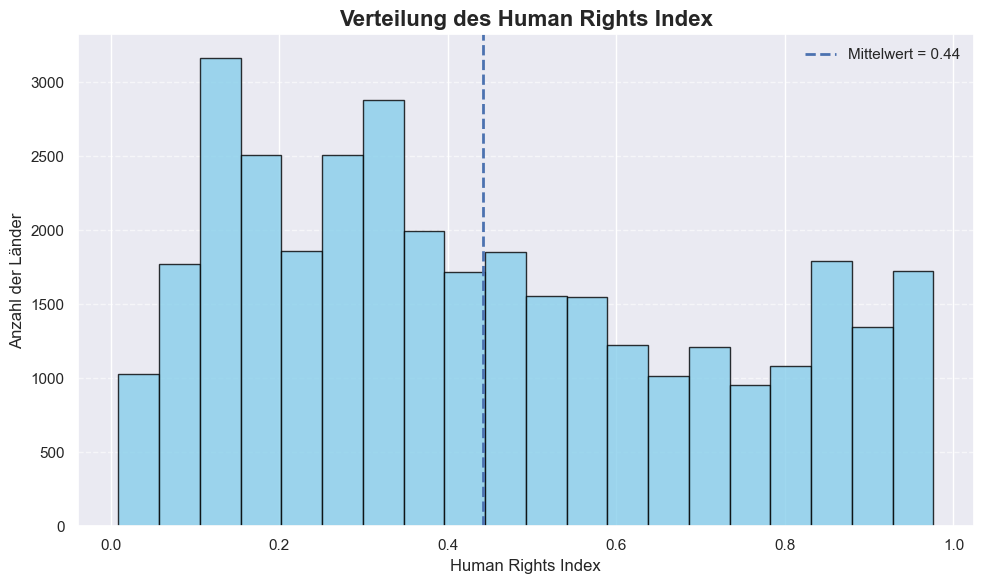

In [36]:
plt.figure(figsize=(10, 6))

plt.hist(
    df['Human Rights Index'].dropna(),
    bins=20,
    color='skyblue',
    edgecolor='black',
    alpha=0.8
)

mean_val = df['Human Rights Index'].mean()
plt.axvline(mean_val, linestyle='--', linewidth=2, label=f'Mittelwert = {mean_val:.2f}')

plt.title("Verteilung des Human Rights Index", fontsize=16, fontweight='bold')
plt.xlabel("Human Rights Index", fontsize=12)
plt.ylabel("Anzahl der Länder", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()


**Boxplot des Human Rights Index**

Der Boxplot zeigt die Verteilung des Human Rights Index mit Fokus auf Median, Quartile und Ausreisser.
Der Median wird berechnet und direkt im Plot als Zahl hervorgehoben, um den zentralen Wert der Daten klar darzustellen.

Median Human Rights Index: 0.385


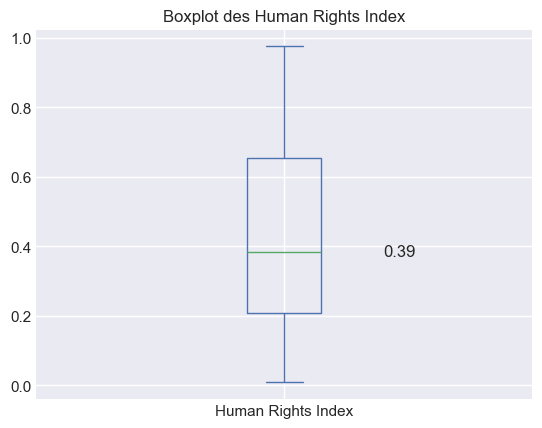

In [27]:

ax = df["Human Rights Index"].plot.box(
    title="Boxplot des Human Rights Index"
)

median = df["Human Rights Index"].median()
print("Median Human Rights Index:", median)


ax.text(
    1.2, median,       
    f"{median:.2f}",     
    va="center"
)

plt.show()


**Boxplot pro 50-Jahres-Abschnitt**

Der Code teilt die Daten in 50‑Jahres‑Abschnitte ein und zeichnet dann Boxplots des Human Rights Index pro Abschnitt.

C:\Users\david\AppData\Local\Temp\ipykernel_30552\3779659506.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


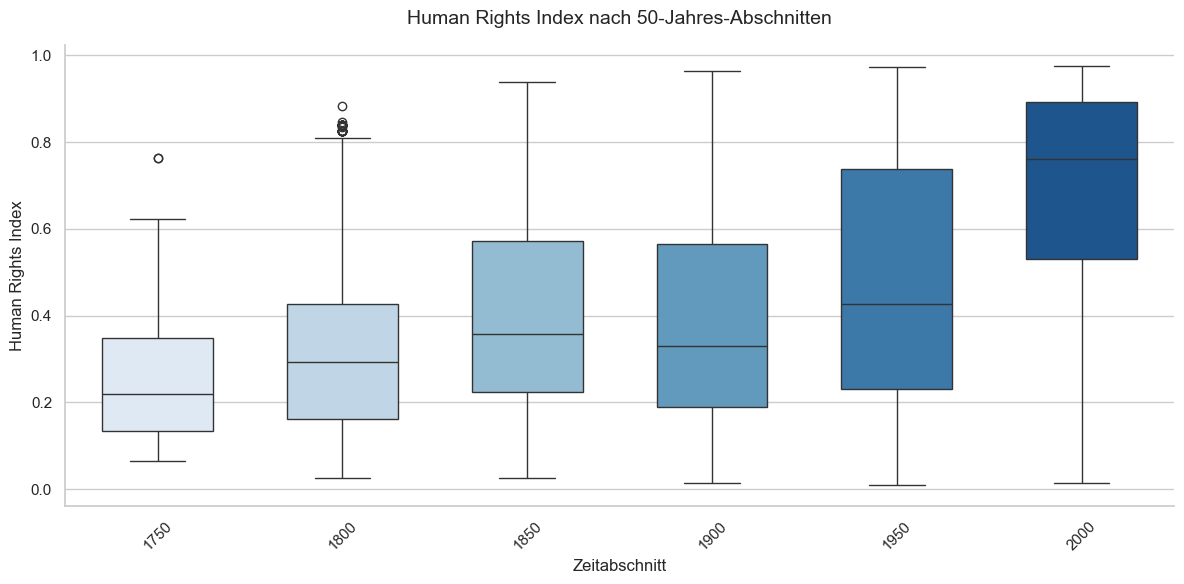

In [11]:
import seaborn as sns

sns.set_theme(style="whitegrid")

df['Abschnitt_50'] = (df['Jahr'] // 50) * 50

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='Abschnitt_50',
    y='Human Rights Index',
    palette="Blues",
    width=0.6
)

plt.title("Human Rights Index nach 50-Jahres-Abschnitten", fontsize=14, pad=15)
plt.xlabel("Zeitabschnitt", fontsize=12)
plt.ylabel("Human Rights Index", fontsize=12)

plt.xticks(rotation=45)

sns.despine()

plt.tight_layout()
plt.show()


**Globaler Durchschnitt des Human Rights Index pro Jahr (alle 5 Jahre)**

Die Grafik zeigt ein Balkendiagramm des globalen durchschnittlichen Human Rights Index für ausgewählte Jahre im Abstand von fünf Jahren, wobei die x‑Achse die Jahre und die y‑Achse den jeweiligen Indexwert darstellt; die Balkenhöhen visualisieren so die zeitliche Entwicklung des Menschenrechtsniveaus.

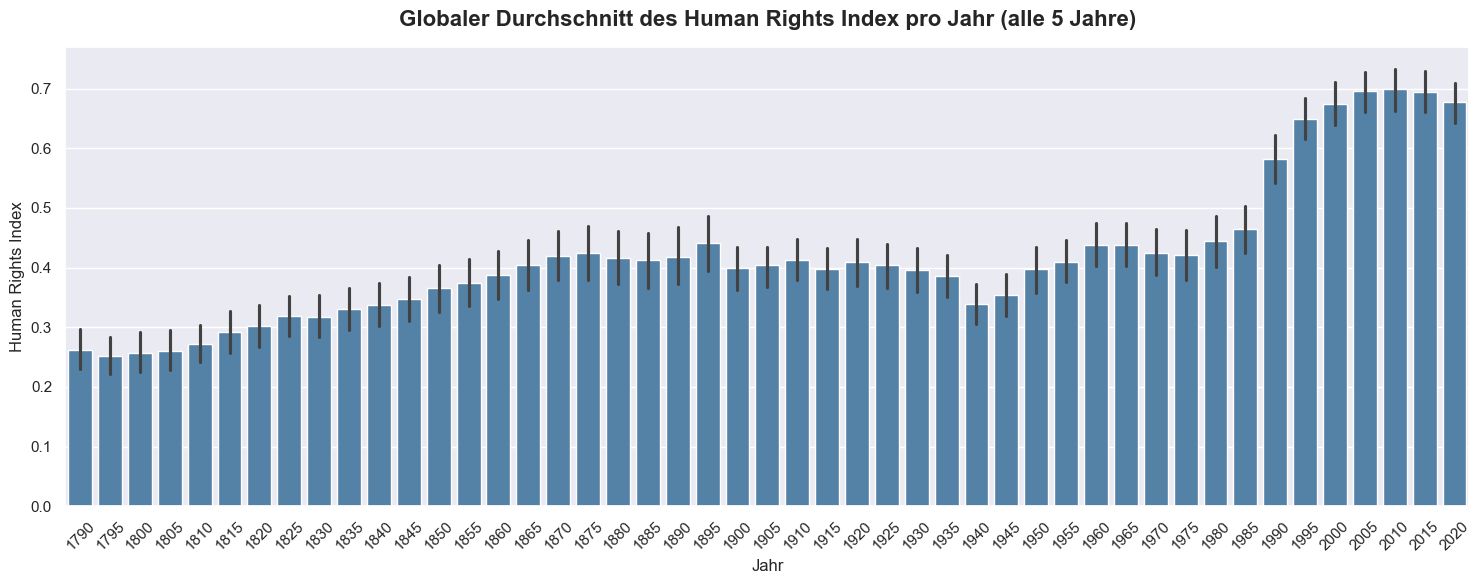

In [33]:
df_5jahre = df[df['Jahr'] % 5 == 0]

plt.figure(figsize=(15, 6))
sns.set_style("darkgrid")

sns.barplot(
    data=df_5jahre,
    x='Jahr',
    y='Human Rights Index',
    color='steelblue'
)

plt.title(
    "Globaler Durchschnitt des Human Rights Index pro Jahr (alle 5 Jahre)",
    fontsize=16,
    fontweight="bold",
    pad=15
)
plt.xlabel("Jahr", fontsize=12)
plt.ylabel("Human Rights Index", fontsize=12)

plt.xticks(rotation=45)  
plt.tight_layout()
plt.show()



### 3.4 Zusammenhänge zwischen Variablen

Unsere zentralen Variablen sind das **Jahr** und der **Human Rights Index**.

**Streuungsdiagramm (Scatter Plot)**

Die Grafik zeigt ein Streudiagramm, in dem für alle Jahre zwischen 1950 und 2024 einzelne Punkte den jeweiligen Wert des Human Rights Index darstellen; die x‑Achse bildet die Jahre ab, die y‑Achse den Index, sodass der zeitliche Verlauf und die Streuung der Menschenrechtslage über diesen Zeitraum sichtbar werden.

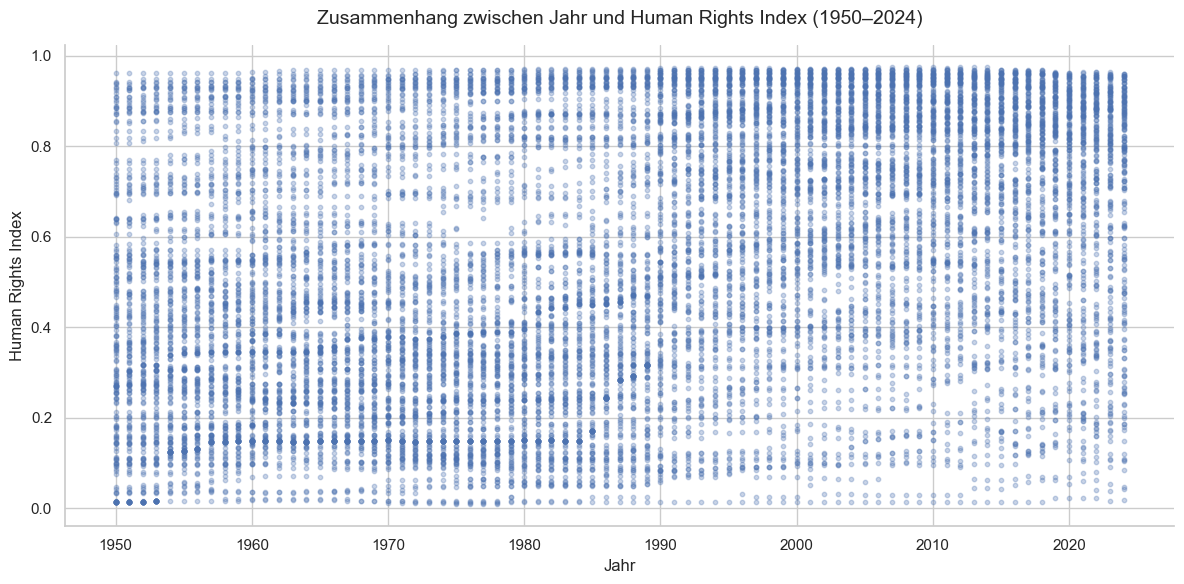

In [32]:
sns.set_theme(style="whitegrid")

df_1950 = df[df["Jahr"].between(1950, 2024)]

plt.figure(figsize=(12, 6))

plt.scatter(
    df_1950["Jahr"],
    df_1950["Human Rights Index"],
    s=10,
    alpha=0.3
)

plt.title("Zusammenhang zwischen Jahr und Human Rights Index (1950–2024)", fontsize=14, pad=15)
plt.xlabel("Jahr", fontsize=12)
plt.ylabel("Human Rights Index", fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()


**Pivot-Tabelle zur Visualisierung der Daten am Beispiel der Schweiz**

Die Grafik zeigt den zeitlichen Verlauf des Human Rights Index für die Schweiz von 1950 bis 2024 als Liniendiagramm, wobei die x‑Achse die Jahre und die y‑Achse den jeweiligen Indexwert abbildet und ein Gitter die Ablesbarkeit der Veränderungen über die Zeit erleichtert.

<Axes: title={'center': 'Veränderung des Human Rights Index – Switzerland'}, xlabel='Jahr', ylabel='Human Rights Index'>

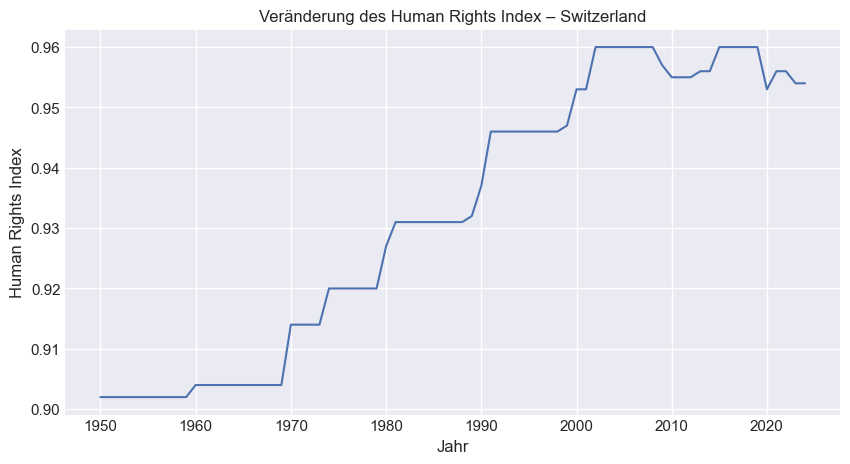

In [31]:
pivot = df.pivot_table(
    index="Jahr",
    columns="Land",
    values="Human Rights Index"
)

land = "Switzerland"

pivot.loc[1950:2024, land].plot(
    title=f"Veränderung des Human Rights Index – {land}",
    xlabel="Jahr",
    ylabel="Human Rights Index",
    grid=True,
    figsize=(10, 5)
)


## 4. Statistik der relevanten Daten (1950-2024)
In diesem Abschnitt werden die Daten erneut statistisch dargestellt, nun jedoch auf den Zeitraum von **1950 bis 2024** gefiltert. Dies ermöglicht eine gezielte Analyse der für unsere Fragestellung relevanten Jahre.

### 4.1 Anzahl der Datenpunkte

Unser gefilterte Datensatz umfasst insgesamt **14'365** Beobachtungen (Datenpunkte).

In [ ]:
df[(df['Jahr'] >= 1950) & (df['Jahr'] <= 2024)]['Human Rights Index'].count()

np.int64(14365)

### 4.2 Fehlen Datenpunkte?

In unserem Datensatz fehlen insgesamt **97** Werte. Diese Anzahl entspricht exakt derjenigen des vollständigen Datensatzes, was darauf hinweist, dass **sämtliche fehlenden Datenpunkte innerhalb des betrachteten Zeitraums liegen**.

In [ ]:
df[(df['Jahr'] >= 1950) & (df['Jahr'] <= 2024)]['Human Rights Index'].isna().sum()

np.int64(97)

### 4.3 Verteilung der Variable (Histogram, Boxplot, Säulendiagramm)

**Histogramm zwischen 1950-2024** 

Die Grafik zeigt ein Histogramm der Verteilung des Human Rights Index für den Zeitraum 1950–2024, wobei die x‑Achse die Wertebereiche des Index in 20 Klassen (Bins) und die y‑Achse die Häufigkeit der Beobachtungen in diesen Bereichen darstellt, sodass erkennbar wird, in welchem Wertebereich sich die meisten Messungen der Menschenrechtslage konzentrieren.

<Axes: title={'center': 'Histogram: Verteilung des Human Rights Index (1950–2024)'}, ylabel='Frequency'>

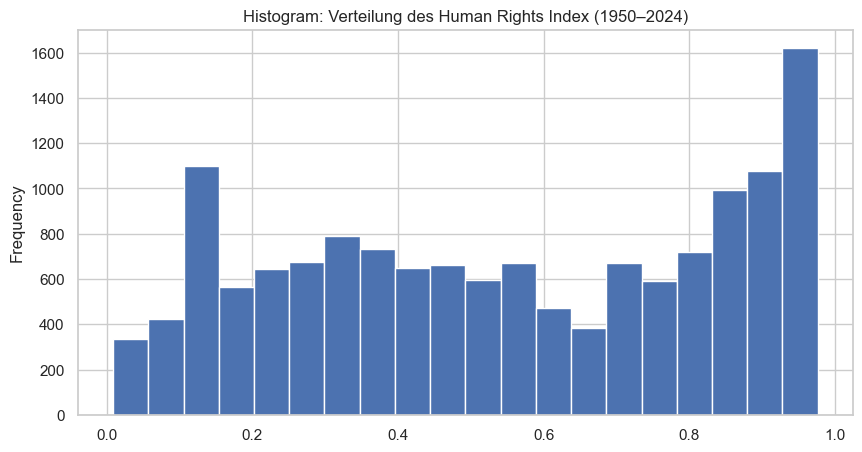

In [17]:
df[(df['Jahr'] >= 1950) & (df['Jahr'] <= 2024)]['Human Rights Index'].plot.hist(
    bins=20,
    figsize=(10, 5),
    title="Histogram: Verteilung des Human Rights Index (1950–2024)"
)


**Boxplot zwischen 1950-2024**

Die Grafik zeigt einen Boxplot des Human Rights Index für den Zeitraum 1950–2024, bei dem auf der y‑Achse die Werte des Index dargestellt sind; Median, Quartile und mögliche Ausreißer machen sichtbar, in welchem Bereich die Menschenrechtswerte typischerweise liegen und wie stark sie im betrachteten Zeitraum streuen.

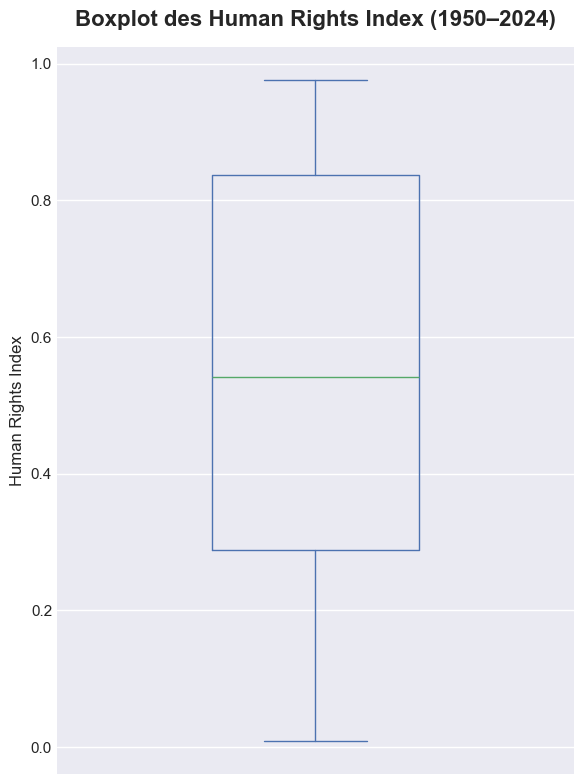

In [ ]:
plt.style.use("seaborn-v0_8-darkgrid")

ax = df[df["Jahr"].between(1950, 2024)]["Human Rights Index"].plot.box(
    figsize=(6, 8),
    widths=0.4
)

ax.set_title(
    "Boxplot des Human Rights Index (1950–2024)",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_ylabel("Human Rights Index", fontsize=12)

# Saubere Optik
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="y", labelsize=11)
ax.set_xticks([])

plt.tight_layout()
plt.show()


**Boxplot nach 10-Jahres-Abschnitten (1950–2024)**

Die Grafik zeigt Boxplots des Human Rights Index für jeweils 10‑Jahres‑Abschnitte zwischen 1950 und 2024, wobei die x‑Achse die Dekaden und die y‑Achse die jeweiligen Indexwerte darstellt; Median, Quartile und Ausreißer machen sichtbar, wie sich Niveau und Streuung der Menschenrechtslage von Dekade zu Dekade verändern.

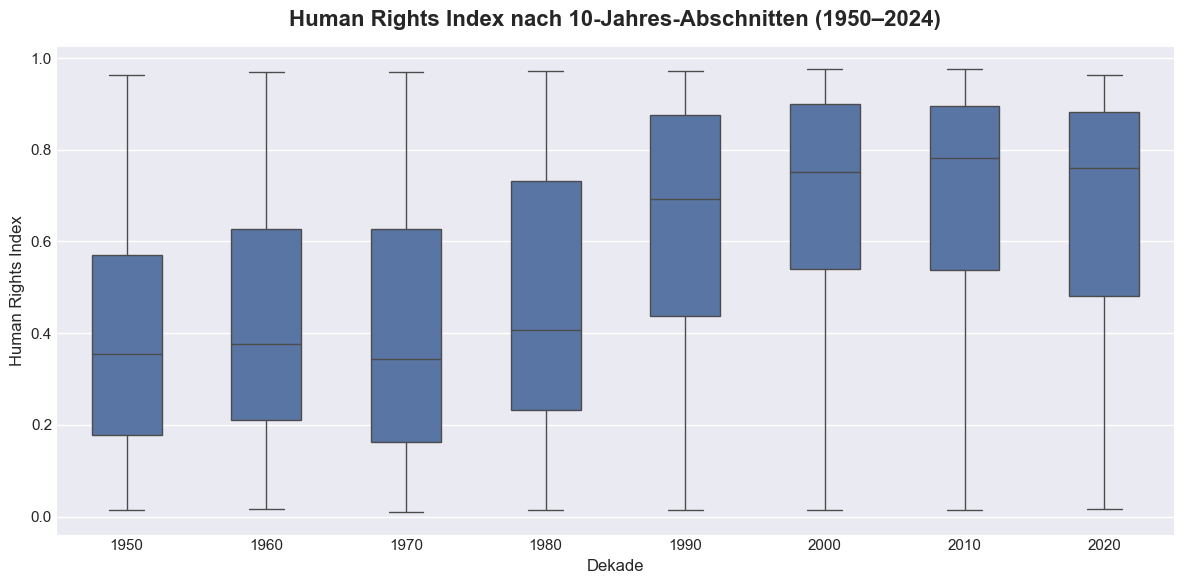

In [ ]:
df_filt = df[df['Jahr'].between(1950, 2024)].copy()

df_filt['Abschnitt_10'] = (df_filt['Jahr'] // 10) * 10

plt.figure(figsize=(12, 6))
sns.set_style("darkgrid")

sns.boxplot(
    data=df_filt,
    x='Abschnitt_10',
    y='Human Rights Index',
    width=0.5
)

plt.title(
    "Human Rights Index nach 10-Jahres-Abschnitten (1950–2024)",
    fontsize=16,
    fontweight="bold",
    pad=15
)
plt.xlabel("Dekade", fontsize=12)
plt.ylabel("Human Rights Index", fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()


**Globaler Durchschnitt des Human Rights Index pro Jahr (1950–2024)**

Die Grafik zeigt ein Balkendiagramm des globalen durchschnittlichen Human Rights Index für jedes Jahr zwischen 1950 und 2024, wobei die x‑Achse die Jahre und die y‑Achse den jeweiligen Indexwert darstellt; die Balkenhöhen machen die jährlichen Schwankungen und Trends im Niveau der Menschenrechtslage über den gesamten Zeitraum sichtbar.

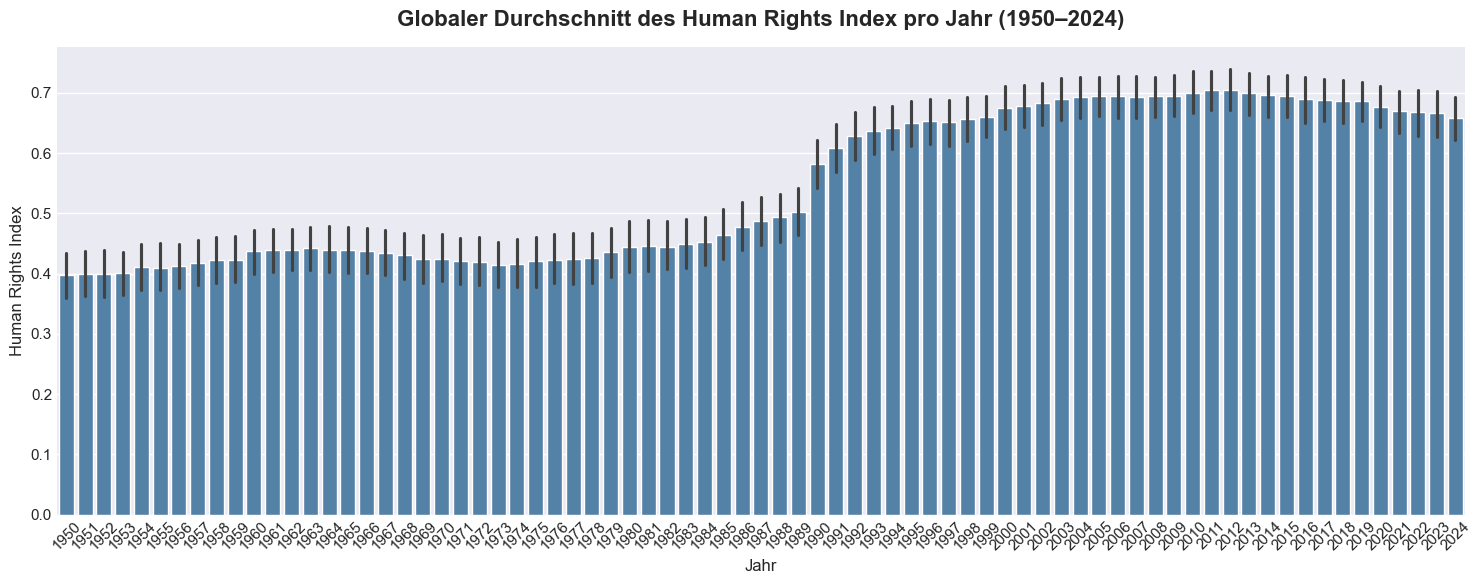

In [ ]:
df_filt = df[df['Jahr'].between(1950, 2024)].copy()

plt.figure(figsize=(15, 6))
sns.set_style("darkgrid")

sns.barplot(
    data=df_filt,
    x='Jahr',
    y='Human Rights Index',
    color='steelblue'
)

plt.title(
    "Globaler Durchschnitt des Human Rights Index pro Jahr (1950–2024)",
    fontsize=16,
    fontweight="bold",
    pad=15
)
plt.xlabel("Jahr", fontsize=12)
plt.ylabel("Human Rights Index", fontsize=12)

plt.xticks(rotation=45)  
sns.despine()
plt.tight_layout()
plt.show()


## 5. Analyse


### 5.1 Abschliessende Visualisierung

**Fragestellung** 

<span style="color:blue; font-weight:bold"> Wie haben sich die Menschenrechte in verschiedenen Ländern in den letzten Jahren entwickelt, und welche drei Staaten verzeichnen die stärksten Verbesserungen bzw. Verschlechterungen zwischen 1950 und 2024?</span> 

**Daten vorbereiten**

Dieser Code filtert zuerst den Datensatz auf den Zeitraum 1950–2024 und wandelt ihn dann in eine Pivot-Tabelle um, in der jede Zeile ein Jahr und jede Spalte ein Land ist, wobei in den Zellen der jeweilige Human Rights Index steht.

In [ ]:
df_filtered = df[(df["Jahr"] >= 1950) & (df["Jahr"] <= 2024)]

pivot = df_filtered.pivot_table(
    index="Jahr",
    columns="Land",
    values="Human Rights Index"
)


**Berechnung der Veränderung 1950 bis 2024**

Der Code berechnet für jedes Land die Veränderung des Human Rights Index zwischen 1950 und 2024, identifiziert daraus die drei Länder mit den größten Verbesserungen und die drei mit den stärksten Verschlechterungen und stellt diese übersichtlich in Tabellen dar.

In [ ]:
start_values = pivot.loc[1950]
end_values = pivot.loc[2024]

diff = end_values - start_values

top_improvements = diff.sort_values(ascending=False).head(3)

top_declines = diff.sort_values(ascending=True).head(3)

import pandas as pd

print("Die stärksten Verbesserungen (1950–2024):")
df_improve = pd.DataFrame({
    "Land": top_improvements.index,
    "Veränderung": top_improvements.values
})
display(df_improve)

print("Die stärksten Verschlechterungen (1950–2024):")
df_decline = pd.DataFrame({
    "Land": top_declines.index,
    "Veränderung": top_declines.values
})
display(df_decline)

Die stärksten Verbesserungen (1950–2024):


,Land,Veränderung
0,Estonia,0.945
1,Latvia,0.924
2,Lithuania,0.899


Die stärksten Verschlechterungen (1950–2024):


,Land,Veränderung
0,Eritrea,-0.462
1,Myanmar,-0.454
2,Cuba,-0.430


**Visualisieren der Fragesellung spezifischen Daten.**

Dank der Berechnung der Länder mit der stärksten positiven Veränderung sowie der stärksten negativen Veränderung im Human Rights Index können wir die Daten nun in einer letzten, anschaulichen Grafik darstellen.
Dazu wurden die beiden Gruppen der Länder als Variablen gespeichert:

In [28]:
laender1 = list(top_improvements.index)
laender2 = list(top_declines.index)

**Stärkste Verbesserungen**

Die zugrunde liegenden Daten werden ausführlich im Abschnitt 5.2 erläutert.

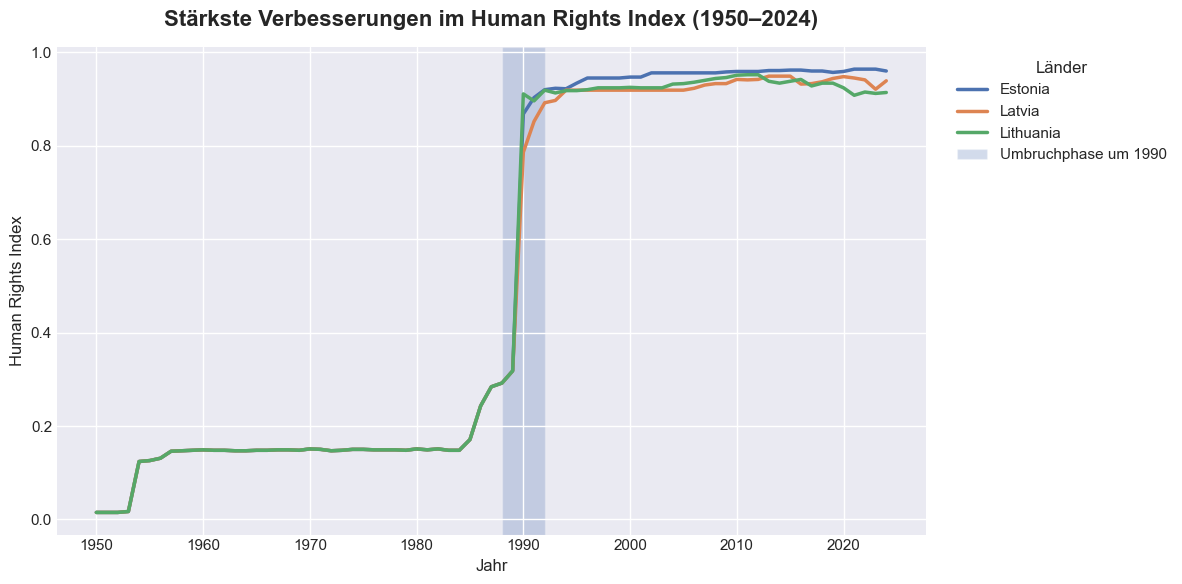

In [29]:
plt.style.use("seaborn-v0_8-darkgrid")

ax = pivot[laender1].plot(
    figsize=(12, 6),
    linewidth=2.5
)


ax.axvspan(
    1988, 1992,
    alpha=0.25,
    zorder=0,
    label="Umbruchphase um 1990"
)

ax.set_title(
    "Stärkste Verbesserungen im Human Rights Index (1950–2024)",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Jahr", fontsize=12)
ax.set_ylabel("Human Rights Index", fontsize=12)

ax.legend(
    title="Länder",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=11)

plt.tight_layout()
plt.show()


**Stärkste Verschlechterungen**

Die zugrunde liegenden Daten werden ausführlich im Abschnitt 5.2 erläutert.

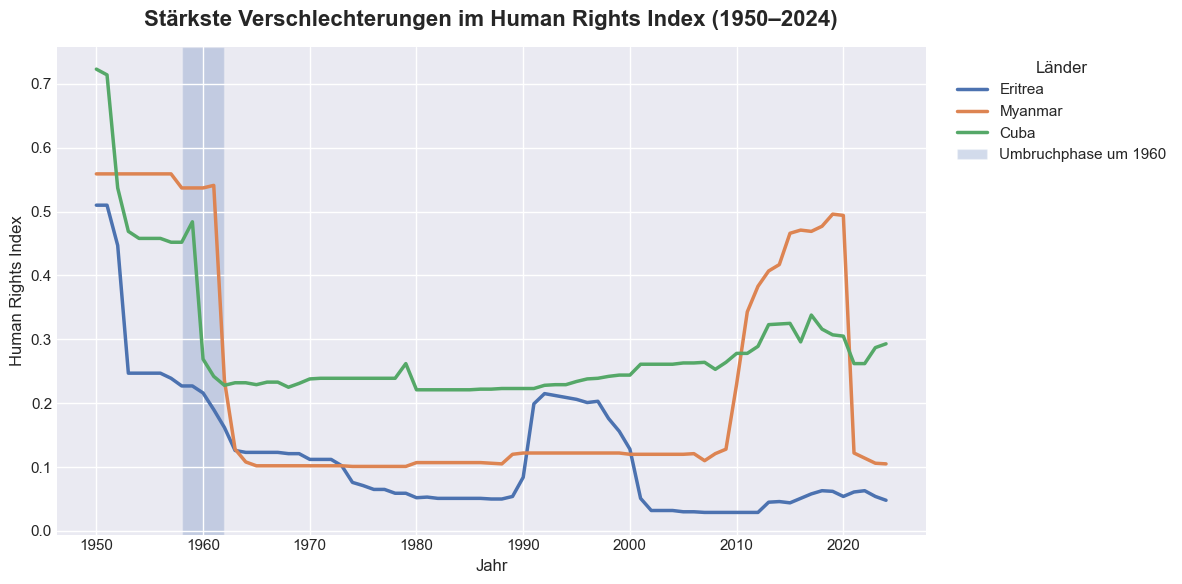

In [30]:
plt.style.use("seaborn-v0_8-darkgrid")

ax = pivot[laender2].plot(
    figsize=(12, 6),
    linewidth=2.5
)

ax.axvspan(
    1958, 1962,  
    alpha=0.25,
    zorder=0,
    label="Umbruchphase um 1960"
)

ax.set_title(
    "Stärkste Verschlechterungen im Human Rights Index (1950–2024)",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Jahr", fontsize=12)
ax.set_ylabel("Human Rights Index", fontsize=12)


ax.legend(
    title="Länder",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)


ax.tick_params(axis="both", labelsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


### 5.2 Beschreibung der Beobachtungen
**Stärkste Verbesserungen des Human Rights Index**


<span style="color:blue; font-weight:bold"> Estonia, </span> 
<span style="color:blue; font-weight:bold"> Latvia, </span>
<span style="color:blue; font-weight:bold"> Lithuania</span>

Aufgrund der grossen Ähnlichkeit der Verläufe des Human Rights Index haben wir uns entschieden, die Beschreibungen dieser Länder zusammenzufassen.



Beschreibung:


Der Graph des Human Rights Indexes steigt bei allen drei Ländern wenig von 1953 bis 1954. Danach bleibt der Graph stabil bis in das Jahr 1984. Ab diesem Jahr zeigt der Graph einen starken Anstieg bis ca. 1990. Zum Schluss verlaufen die drei Graphen nahezu konstant bis 2024. 

**Stärkste Verschlechterungen des Human Rights Index**



<span style="color:red; font-weight:bold"> Erithrea</span>


Beschreibung:


Der Index liegt zu Beginn der 1950er Jahre bei 0,5 und fällt innerhalb von ca. 3 Jahren auf etwa 0,25. Danach setzt sich der Abwärtstrend bis 1960 langsamer fort. Von 1960 bis 1970 bleibt der Graph stabil. Ab den 1970er Jahren sinkt der Index schrittweise bis 1988. Anschliessend sieht man eine deutliche Verbesserung bis 1991. Diese Erholung ist jedoch nicht von Dauer, da der Wert gegen Ende der 1990er Jahre erneut stark sinkt und zu Beginn der 2000er-Jahre unter ca. 0,05 fällt. In den folgenden Jahren bleibt der Index niedrig und verbessert sich nur wenig von 2012 bis 2024. 


<span style="color:red; font-weight:bold"> Myanmar</span>



Beschreibung:


Anfangs der 1950er-Jahre bis ca. 1961 ist der Index ziemlich stabil und liegt hoch. Nach 1961 ist ein sehr starker Einbruch ersichtlich. Der Index liegt 1964 bei 0,1 und ändert sich bis in das Jahr 1980 fast nicht. Anschliessend erhöht sich der Graph sehr schwach. Ab 2009 ist eine deutliche Verbesserung erkennbar, da der Graph bis 2020 auf 0,5 steigt. Zum Schluss bricht der Index massiv ein und erreicht erneut 0,1. 


<span style="color:red; font-weight:bold"> Cuba</span>



Beschreibung:


Der Graph für Kuba liegt zu Beginn der 1950er Jahre im Vergleich zu den anderen Graphen ziemlich hoch mit einem Wert über 0,7. In den darauffolgenden Jahren sinkt der Graph bis Ende der 1960er-Jahre um ca. 0,35. Dieser Rückgang wiederholt sich direkt danach nochmals und der Index liegt 1960 bei 0,25. Der Graph bleibt lange auf diesem tiefen Niveau mit wenigen Schwankungen. Anfangs der 2000er Jahre steigt der Graph leicht bis 2017. Gegen Ende sinkt der Graph wieder und erholt sich leicht, sodass der Schlusswert 2024 bei 0,3 liegt. 


### 5.3 Interpretation der Resultate (Hypothesen zu den Resultaten)


Deutung der Ergebnisse und ihre Absicherung durch Verweise auf relevante Fachliteratur.

In [26]:
from IPython.display import Image, display

**Stärkste Verbesserungen des Human Rights Index**


<span style="color:blue; font-weight:bold"> Estonia</span> <img src="ee.png" width="200" style="float:right; margin:10px">




Interpretation:


Estland wurde vor 1950 (im Zweiten Weltkrieg) einige Male besetzt durch Deutschland und die Sowjetunion. Die Rote Armee gewann die Oberhand und besetzte Estland. Der tiefe Anfang des Graphen lässt sich begründen, da vor 1950 das Land von Terror, Repression, Deportation und massivem Bevölkerungsverlust geprägt war. 1991 wurde eine Volksabstimmung  durchgeführt, in welcher die Mehrheit der Bevölkerung für die Wiederherstellung der staatlichen Unabhängigkeit Estlands war. Im selben Jahr wurde ein  Putschversuch in Moskau durch die Kommunistische Partei der Sowjetunion durchgeführt, welcher scheiterte. Diese grosse Veränderung ist im Human-Right-Index ersichtlich, da der Graph drastisch steigt. Nach diesem Jahr bis 2024 bleibt der Graph trotz eines gewaltsamen Protests stabil.  


Quelle: https://de.wikipedia.org/wiki/Geschichte_Estlands






<span style="color:blue; font-weight:bold"> Latvia</span> <img src="lv.png" width="200" style="float:right; margin:10px">




Interpretation:


Wie sich bei den drei fast identischen Graphen vermuten lässt, ist auch Lettland vor 1950 von der Roten Armee besetzt worden, weshalb der Anfang des Graphen so tief sitzt. Im selben Jahr wie Litauen wird Lettland für unabhängig erklärt. Lettland wurde anfangs dieser Zeit als wirtschaftlich und politisch instabil gehalten, jedoch erlebte das Land in den 1990er-Jahren einen wirtschaftlichen Aufschwung, welcher sich auch im Human-Rights-Index erblicken lässt. 

Quelle: https://de.wikipedia.org/wiki/Geschichte_Lettlands 




<span style="color:blue; font-weight:bold"> Lithuania</span> <img src="lt.png" width="200" style="float:right; margin:10px">



Interpretation:


Litauen hat eine ähnliche Geschichte wie Estland, da dieses Land vor 1950 von der Roten Armee besetzt wurde. Auch Litauen wurde durch Deportation und Terror geprägt, weswegen der Graph des Human-Rights-Index tief beginnt. 1990 wurde durch freie Wahlen die Unabhängigkeitserklärung verabschiedet. Ähnlich versuchten moskautreue Kräfte mit Unterstützung des sowjetischen Militärs an die Macht zu putschen. Der Putsch misslang. Diese grosse Veränderung im Land  ist im Human-Right-Index ersichtlich, da der Graph drastisch steigt. 

Quelle: https://de.wikipedia.org/wiki/Geschichte_Litauens 




**Stärkste Verschlechterungen des Human Rights Index**





<span style="color:red; font-weight:bold"> Erithrea</span> <img src="er.png" width="200" style="float:right; margin:10px">


Interpretation:

Die starke Abnahme des Human-Rights-Index 1952 lässt sich mit der Unabhängigkeit von Eritrea begründen. Ab dem 15. September wurde Eritrea gegen seinen Willen durch die Entscheidung der United Nations Teilstaat von Äthiopien. Ab 1961 wird Eritrea vollständig annektiert und ein 30-jähriger Befreiungskampf bricht aus. 1991 wird das Mengitsu-Regime gestürzt und äthiopische Truppen ziehen aus Eritrea ab. Ab diesem Zeitpunkt sieht man eine Erhöhung des Graphen bis ca. 1993. In diesem Jahr wird Eritrea durch eine Abstimmung von Äthiopien getrennt und wird unabhängig. Das Land wird durch rund 70'000 ehemalige Freiheitskämpfer wieder aufgebaut. Im Jahr 1998 brechen wieder erneut schwere Kämpfe aus, diesmal an der Grenze. Dies ist auch im Human-Rights-Index ersichtlich, da sich der Graph wieder senkt. Seitdem hat sich der Graph fast stetig verhalten.  


Quelle: https://www1.wdr.de/stichtag/stichtag-eritrea-autonomie-aethiopien-100.html 




<span style="color:red; font-weight:bold"> Myanmar</span> <img src="mm.png" width="200" style="float:right; margin:10px">



Interpretation:


Myanmar wurde vor 1950 von Japan und Britannien besetzt. Ab 1948 wurde das Land als unabhängig anerkannt. Seit dieser Unabhängigkeit gab es verschiedene bewaffnete Konflikte in einigen Landesteilen. Ab 1962 wurde Myanmar von verschiedenen Militärregimen kontrolliert. Genau in diesem Jahr sieht man im Human-Rights-Index einen tiefen Fall des Graphen. Zwischen den Jahren 1965-1988 gab es einige Ereignisse wie z.B. die Verstaatlichung von Wirtschaftsunternehmen, die Ausweisung von christlichen Missionaren und eine gewaltsame Niederschlagung eines Protestes 1988. In diesem Jahr sieht man eine leichte Steigung des Graphen, da sich ein neues Militärregime als Staatsrat etablierte. Ab 2010 sieht man ein deutliches Wachstum des Graphen. Dies könnte mit den Wahlen in Korrelation stehen, da es seit 1990 keine mehr gab. Ab dem Jahr 2020  verschlechtert sich der Human-Rights-Index extrem. Dies steht mit dem Militärputsch von 2021 in Zusammenhang, welcher die demokratisch gewählte Regierung entmachtete. In den nachfolgenden Jahren gab es Massenproteste, politische Repression und Hinrichtungen von Politikern.  


Quelle: https://de.wikipedia.org/wiki/Myanmar 




<span style="color:red; font-weight:bold"> Cuba</span> <img src="cu.png" width="200" style="float:right; margin:10px">



Interpretation:


Wenige Jahre vor 1950 regierte der Präsident Grau San Martin das Land. Batista, ein vorheriger machtbesessener Präsident, der 1952 der Anführer eines Militärputsches war, errichtete ein autoritäres Regime. In diesem Jahr senkt sich der Graph des Human-Right-Index. Einem jungen Rechtsanwalt namens Fidel Castro gelang es 1959, durch einen bewaffneten Widerstand den Diktator in die Flucht zu schlagen. Eine erneute Senkung des Graphen lässt sich feststellen. Fidel Castro übernahm im selben Jahr das Amt des Ministerpräsidenten, was in Zusammenhang mit Graphen stehen könnte. Zwischen den Jahren 1960-2006 geschah einiges, wie z.B. die bekannte Kuba-Krise im Jahr 1962. Im Jahr 2006 übertrug Fidel Castro die Amtsgeschäfte seinem Bruder. Ab diesem Jahr schwankt der Graph auf und ab bis ca. ins Jahr 2018, in welchem der Bruder von Fidel Castro abgelöst wurde. Nach dieser Amtsübergabe sank der Graph bis 2021 und stieg ab diesem Jahr wieder wenig. 


Quelle: https://kuba.de/infos/geschichte/ 


### 5.3 Abschliessende Worte zum Dokument

Das Dokument bietet eine systematische, gut nachvollziehbare Analyse des Human Rights Index über den Zeitraum 1950–2024.

Insgesamt schafft das Notebook eine solide quantitative Grundlage, auf deren Basis weiterführende inhaltliche Interpretationen und Vergleiche zwischen Ländern sinnvoll aufbauen können.​